In [199]:
import numpy as np

from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFTGate, DiagonalGate, StatePreparation
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator

In [ ]:
n = 8                      
m = 4                     
N = 2 ** n                 
dt = 0.01                  
num_steps = 500           
#shots = 2048           
shots = 10            
x_max = 10.0
x = np.linspace(-x_max, x_max, N, endpoint=False)
dx = x[1] - x[0]



g = 1

PRINT_EACH_MODE = True
#PRINT_EACH_MODE = False

DEBUG_EXACT = True
#DEBUG_EXACT = False

retained_modes = list(range(2 ** (m - 1))) + list(range(N - 2 ** (m - 1), N))


backend = AerSimulator()


In [ ]:

def build_initial_state_circuit(n, psi0):
    qc = QuantumCircuit(n, name="A_init")
    #qc.initialize(psi0, list(range(2*n)), normalize=True)
    qc.append(StatePreparation(psi0, normalize=True), range(n))
    return qc

In [ ]:
def build_fixed_linear_gate_from_k(k, dt):
    phase = np.exp(-1j * (k ** 2) * dt / 4.0)
    return DiagonalGate(phase)

In [ ]:

def build_one_step_circuit(n, fixed_gate, nonlinear_gate):
    qc = QuantumCircuit(n, name="OneStep")

    qft = QFTGate(n)
    iqft = qft.inverse()

    qc.append(qft, range(n))
    qc.append(fixed_gate, range(n))
    qc.append(iqft, range(n))

    qc.append(nonlinear_gate, range(n))

    qc.append(qft, range(n))
    qc.append(fixed_gate, range(n))
    qc.append(iqft, range(n))

    return qc


In [ ]:
def build_prefix_before_nonlinear_from_statevector(n, previous_full_state, fixed_gate):
    qc = QuantumCircuit(n, name="PrefixBeforeNL_fromSV")

    qc.append(StatePreparation(previous_full_state.data, normalize=True), range(n))

    qft = QFTGate(n)
    qc.compose(qft, qubits=list(range(n)), inplace=True)
    qc.append(fixed_gate, range(n))

    return qc


In [ ]:
def build_prefix_before_nonlinear_circuit(n, init_circuit, fixed_gate, nonlinear_gates_done):

    qc = QuantumCircuit(n, name="PrefixBeforeNL")

    qc.compose(init_circuit, inplace=True)

    for D_prev in nonlinear_gates_done:
        one_step = build_one_step_circuit(n, fixed_gate, D_prev)
        qc.compose(one_step, inplace=True)

    qft = QFTGate(n)
    iqft = qft.inverse()
    qc.append(qft, range(n))
    qc.append(fixed_gate, range(n))

    return qc



In [ ]:

def build_total_evolution_circuit(n, init_circuit, fixed_gate, nonlinear_gates):
    qc = QuantumCircuit(n, name="TotalEvolution")
    qc.compose(init_circuit, inplace=True)

    for D_nl in nonlinear_gates:
        one_step = build_one_step_circuit(n, fixed_gate, D_nl)
        qc.compose(one_step, inplace=True)

    return qc



In [ ]:
def build_basis_mode_encoding_circuit(n, mode_index):

    qc = QuantumCircuit(n, name=f"S_basis_{mode_index}")
    bits = format(mode_index, f"0{n}b")

    for q, bit in enumerate(reversed(bits)):
        if bit == "1":
            qc.x(q)

    return qc


In [ ]:

def build_overlap_unitary(prefix_circuit, mode_encoding_circuit):

    n = prefix_circuit.num_qubits
    qc = QuantumCircuit(n, name="U_overlap")

    qc.compose(prefix_circuit, inplace=True)
    qc.compose(mode_encoding_circuit.inverse(), inplace=True)

    return qc


<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
C:\Users\16237\AppData\Local\Temp\ipykernel_26108\3288090210.py:7: SyntaxWarning: invalid escape sequence '\d'
  U = S_k^\dagger · Prefix


In [ ]:
def build_hadamard_test_circuit(overlap_unitary_circuit, part="real"):

    n_data = overlap_unitary_circuit.num_qubits

    qc = QuantumCircuit(n_data + 1, 1, name=f"HT_{part}")

    anc = 0
    data_qubits = list(range(1, n_data + 1))

    U_gate = overlap_unitary_circuit.to_gate(label="U_overlap")
    cU_gate = U_gate.control(1)

    qc.h(anc)
    qc.append(cU_gate, [anc] + data_qubits)

    if part == "real":
        qc.h(anc)
    elif part == "imag":
        qc.sdg(anc)
        qc.h(anc)

    qc.measure(anc, 0)
    return qc

In [ ]:
def run_hadamard_test(qc, backend, shots=2048):

    tqc = transpile(qc, backend, optimization_level=0)
    result = backend.run(tqc, shots=shots).result()
    counts = result.get_counts()

    p0 = counts.get("0", 0) / shots
    p1 = counts.get("1", 0) / shots
    expectation = p0 - p1

    return expectation, counts


In [ ]:
def estimate_one_mode_amplitude(prefix_circuit, mode_encoding_circuit, backend, shots=2048):
  
    overlap_u = build_overlap_unitary(prefix_circuit, mode_encoding_circuit)

    qc_real = build_hadamard_test_circuit(overlap_u, part="real")
    re_val, counts_real = run_hadamard_test(qc_real, backend, shots=shots)

    qc_imag = build_hadamard_test_circuit(overlap_u, part="imag")
    im_val, counts_imag = run_hadamard_test(qc_imag, backend, shots=shots)

    amp = re_val + 1j * im_val

    details = {
        "counts_real": counts_real,
        "counts_imag": counts_imag,
        "qc_real": qc_real,
        "qc_imag": qc_imag,
    }
    return amp, details

In [ ]:
def exact_mode_amplitude_from_prefix(prefix_circuit, mode_index):

    sv = Statevector.from_instruction(prefix_circuit).data
    return sv[mode_index]


def amplitudes_dict_to_full_spectrum(n, retained_modes, amplitudes_dict):

    N = 2 ** n
    spectrum = np.zeros(N, dtype=complex)

    for mode in retained_modes:
        spectrum[mode] = amplitudes_dict.get(mode, 0.0 + 0.0j)

    return spectrum

In [ ]:

def reconstruct_position_wavefunction_from_modes(n, retained_modes, amplitudes_dict):

    spectrum = amplitudes_dict_to_full_spectrum(n, retained_modes, amplitudes_dict)
    #psi_recon = np.fft.ifft(spectrum)
    psi_recon = np.fft.fft(spectrum, norm="ortho")
    return psi_recon, spectrum

In [ ]:

def build_nonlinear_gate_from_reconstruction(n, retained_modes, amplitudes_dict, g, dt):

    psi_recon, spectrum = reconstruct_position_wavefunction_from_modes(
        n=n,
        retained_modes=retained_modes,
        amplitudes_dict=amplitudes_dict
    )

    diag = np.exp(-1j * g * dt * np.abs(psi_recon) ** 2)
    gate = DiagonalGate(diag)

    return gate, psi_recon, spectrum

In [ ]:
def initial_state_soliton(x, beta=0.5, xc=0.0, v=2.0):
    profile = 1.0 / np.cosh(beta * (x - xc))

    A = 1.0 / np.linalg.norm(profile)


    psi = A * profile * np.exp(1j *0.5 * v * (x - xc))

    g = - beta**2 / A**2

    return psi, g, A

In [ ]:

if __name__ == "__main__":


    psi, g, A = initial_state_soliton(x)

    init_circuit = build_initial_state_circuit(n, psi)


    freq = np.fft.fftfreq(N, d=dx)
    k = 2.0 * np.pi * freq

    fixed_gate = build_fixed_linear_gate_from_k(k, dt)


    nonlinear_gates = []                     
    prefix_circuit_history = []             
    total_circuit_history = []            
    amplitude_history = []                  
    reconstructed_wavefunction_history = [] 
    reconstructed_spectrum_history = []   
    

    statevector_history = []                
    wavefunction_history = []               
    density_history = []                  
    times = []                              
    

    current_state = Statevector(psi)

    statevector_history.append(current_state)
    wavefunction_history.append(current_state.data.copy())
    density_history.append(np.abs(current_state.data) ** 2)
    times.append(0.0)

    total_circuit_so_far = QuantumCircuit(n, name="TotalEvolution")
    total_circuit_so_far.compose(init_circuit, inplace=True)




    for step in range(num_steps):
        if step % 1 == 0:
            print(f"\n===== Step {step + 1} =====")



        prefix_circuit = build_prefix_before_nonlinear_from_statevector(
            n=n,
            previous_full_state=current_state,
            fixed_gate=fixed_gate
        )
  
        '''
        prefix_circuit = build_prefix_before_nonlinear_circuit(
            n=n,
            init_circuit=init_circuit,
            fixed_gate=fixed_gate,
            nonlinear_gates_done=nonlinear_gates
        )
        '''
        prefix_circuit_history.append(prefix_circuit)


        amplitudes_this_step = {}

        for mode in retained_modes:
            mode_encoding = build_basis_mode_encoding_circuit(n, mode)

            amp_est, detail = estimate_one_mode_amplitude(
                prefix_circuit=prefix_circuit,
                mode_encoding_circuit=mode_encoding,
                backend=backend,
                shots=shots
            )

            amplitudes_this_step[mode] = amp_est

            if DEBUG_EXACT:
                amp_exact = exact_mode_amplitude_from_prefix(prefix_circuit, mode)
            else:
                amp_exact = None

            if PRINT_EACH_MODE:
                if DEBUG_EXACT:
                    print(
                        f"mode = {mode:3d} | "
                        f"Hadamard = {amp_est.real:+.6f}{amp_est.imag:+.6f}j | "
                        f"Exact = {amp_exact.real:+.6f}{amp_exact.imag:+.6f}j"
                    )
                else:
                    print(
                        f"mode = {mode:3d} | "
                        f"Hadamard = {amp_est.real:+.6f}{amp_est.imag:+.6f}j"
                    )

        amplitude_history.append(amplitudes_this_step)


        D_step, psi_recon, spectrum_recon = build_nonlinear_gate_from_reconstruction(
            n=n,
            retained_modes=retained_modes,
            amplitudes_dict=amplitudes_this_step, 
            g=g,
            dt=dt
        )

        reconstructed_wavefunction_history.append(psi_recon)
        reconstructed_spectrum_history.append(spectrum_recon)

  
        nonlinear_gates.append(D_step)

        
        '''

        total_circuit = build_total_evolution_circuit(
            n=n,
            init_circuit=init_circuit,
            fixed_gate=fixed_gate,
            nonlinear_gates=nonlinear_gates
        )
        total_circuit_history.append(total_circuit)

        state_now = Statevector.from_instruction(total_circuit)
        psi_now = state_now.data.copy()
        density_now = np.abs(psi_now) ** 2

        statevector_history.append(state_now)
        wavefunction_history.append(psi_now)
        density_history.append(density_now)
        times.append((step + 1) * dt)

        '''

        one_step_circuit = build_one_step_circuit(
            n=n,
            fixed_gate=fixed_gate,
            nonlinear_gate=D_step
        )


        current_state = current_state.evolve(one_step_circuit)


        new_total_circuit = QuantumCircuit(n, name="TotalEvolution")
        new_total_circuit.compose(total_circuit_so_far, inplace=True)
        new_total_circuit.compose(one_step_circuit, inplace=True)
        total_circuit_so_far = new_total_circuit

        total_circuit_history.append(total_circuit_so_far)


        state_now = current_state
        psi_now = state_now.data.copy()
        density_now = np.abs(psi_now) ** 2

        statevector_history.append(state_now)
        wavefunction_history.append(psi_now)
        density_history.append(density_now)
        times.append((step + 1) * dt)


        #recon_norm = np.linalg.norm(psi_recon)
        #max_density = np.max(np.abs(psi_recon) ** 2)
        #print(f"Reconstructed ||psi|| = {recon_norm:.6f}")
        #print(f"Max reconstructed |psi|^2 = {max_density:.6f}")

    

    final_state = Statevector.from_instruction(total_circuit_history[-1]).data
    final_density = np.abs(final_state) ** 2

    print(f"Final state norm = {np.linalg.norm(final_state):.6f}")
    print(f"Final max |psi|^2 = {np.max(final_density):.6f}")



===== Step 1 =====
mode =   0 | Hadamard = -0.600000+0.200000j | Exact = +0.060305+0.000064j
mode =   1 | Hadamard = -0.600000-0.200000j | Exact = -0.023072+0.000070j
mode =   2 | Hadamard = +0.400000-0.200000j | Exact = +0.007952+0.000056j
mode =   3 | Hadamard = -0.200000-0.200000j | Exact = -0.003618+0.000072j
mode =   4 | Hadamard = -0.200000+0.000000j | Exact = +0.000719+0.000061j
mode =   5 | Hadamard = +0.000000-0.400000j | Exact = -0.000864+0.000069j
mode =   6 | Hadamard = +0.000000+0.000000j | Exact = -0.000238+0.000066j
mode =   7 | Hadamard = -0.400000-0.200000j | Exact = -0.000436+0.000069j
mode = 248 | Hadamard = +0.000000+0.000000j | Exact = +0.013578-0.000150j
mode = 249 | Hadamard = +0.000000+0.200000j | Exact = -0.030548+0.000433j
mode = 250 | Hadamard = +0.000000+0.000000j | Exact = +0.089442-0.000730j
mode = 251 | Hadamard = -0.200000+0.000000j | Exact = -0.223704+0.001444j
mode = 252 | Hadamard = +0.200000+0.000000j | Exact = +0.528419-0.002022j
mode = 253 | Hadam

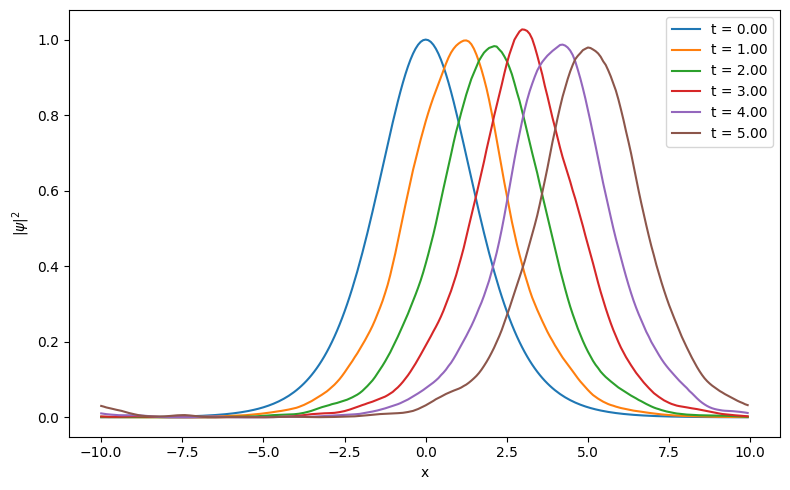

图片已保存为: density_n8_nreduce4_steps500_dt0p01_shots10_xmax10.0.png


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for step in range(len(density_history)):
    if step % 100 == 0:
        plt.plot(x, density_history[step]/A**2, label=f"t = {times[step]:.2f}")

plt.xlabel("x")
plt.ylabel(r"$|\psi|^2$")
plt.legend()
plt.tight_layout()

dt_str = f"{dt:.2f}".replace(".", "p")
filename = f"density_n{n}_nreduce{m}_steps{num_steps}_dt{dt_str}_shots{shots}_xmax{x_max}.png"

plt.savefig(filename, dpi=300, bbox_inches="tight")
plt.show()




In [218]:
def build_npz_filename(init_name, shots, num_steps, dt, n, m, extra_tag=None):
    dt_str = f"{dt:.2f}".replace(".", "p")
    name = f"qnlse_{init_name}_n{n}_m{m}_shots{shots}_steps{num_steps}_dt{dt_str}"
    name += f"_x_max{x_max}"
    if extra_tag is not None and extra_tag != "":
        name += f"_{extra_tag}"
    name += ".npz"
    return name


def save_run_to_npz(
    init_name,
    shots,
    num_steps,
    dt,
    n,
    m,
    times,
    wavefunction_history,
    density_history,
    #reconstructed_wavefunction_history,
    #reconstructed_spectrum_history,
    filename=None,
    extra_tag=None,
    compressed=True
):
    if filename is None:
        filename = build_npz_filename(init_name, shots, num_steps, dt, n, m, extra_tag)


    save_func = np.savez_compressed if compressed else np.savez

    save_func(
        filename,
        init_name=np.array(init_name),
        shots=np.array(shots),
        num_steps=np.array(num_steps),
        dt=np.array(dt),
        n=np.array(n),
        N=np.array(2**n),
        times=np.array(times, dtype=float),
        wavefunction_history=np.array(wavefunction_history, dtype=complex),
        density_history=np.array(density_history, dtype=float),
        #reconstructed_wavefunction_history=np.array(reconstructed_wavefunction_history, dtype=complex),
        #reconstructed_spectrum_history=np.array(reconstructed_spectrum_history, dtype=complex),
    )

    return filename

In [219]:
init_name = "basis0"

In [ ]:
saved_file = save_run_to_npz(
    init_name=init_name,
    shots=shots,
    num_steps=num_steps,
    dt=dt,
    n=n,
    m=m, 
    times=times,
    wavefunction_history=wavefunction_history,
    density_history=density_history,
    #reconstructed_wavefunction_history=reconstructed_wavefunction_history,
    #reconstructed_spectrum_history=reconstructed_spectrum_history,
    #amplitude_history=amplitude_history,
    extra_tag="run1",
    compressed=True
)


结果已保存到: qnlse_basis0_n8_m4_shots10_steps500_dt0p01_x_max10.0_run1.npz
